In [2]:
import pandas as pd


In [3]:
d=pd.read_csv("Salary Data.csv")
d

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [4]:
d.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [5]:
d.columns[d.isnull().any()]

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [6]:
d = d.drop(["Education Level"], axis=1)
d

,Age,Gender,Job Title,Years of Experience,Salary
0,32.0,Male,Software Engineer,5.0,90000.0
1,28.0,Female,Data Analyst,3.0,65000.0
2,45.0,Male,Senior Manager,15.0,150000.0
3,36.0,Female,Sales Associate,7.0,60000.0
4,52.0,Male,Director,20.0,200000.0
...,...,...,...,...,...
370,35.0,Female,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Director of Operations,19.0,170000.0
372,29.0,Female,Junior Project Manager,2.0,40000.0
373,34.0,Male,Senior Operations Coordinator,7.0,90000.0


In [7]:
d["Gender"].value_counts()

Male      194
Female    179
Name: Gender, dtype: int64

In [8]:
e = pd.get_dummies(d["Gender"])
e

,Female,Male
0,0,1
1,1,0
2,0,1
3,1,0
4,0,1
...,...,...
370,1,0
371,0,1
372,1,0
373,0,1


In [9]:
d = pd.concat([d, e], axis=1)
d

,Age,Gender,Job Title,Years of Experience,Salary,Female,Male
0,32.0,Male,Software Engineer,5.0,90000.0,0,1
1,28.0,Female,Data Analyst,3.0,65000.0,1,0
2,45.0,Male,Senior Manager,15.0,150000.0,0,1
3,36.0,Female,Sales Associate,7.0,60000.0,1,0
4,52.0,Male,Director,20.0,200000.0,0,1
...,...,...,...,...,...,...,...
370,35.0,Female,Senior Marketing Analyst,8.0,85000.0,1,0
371,43.0,Male,Director of Operations,19.0,170000.0,0,1
372,29.0,Female,Junior Project Manager,2.0,40000.0,1,0
373,34.0,Male,Senior Operations Coordinator,7.0,90000.0,0,1


In [10]:
d["Years of Experience"] = d["Years of Experience"].fillna(
    d["Years of Experience"].mean()
)
d["Years of Experience"]

0       5.0
1       3.0
2      15.0
3       7.0
4      20.0
       ... 
370     8.0
371    19.0
372     2.0
373     7.0
374    15.0
Name: Years of Experience, Length: 375, dtype: float64

In [11]:
d["Salary"] = d["Salary"].fillna(
    d["Salary"].mean()
)
d["Salary"]

0       90000.0
1       65000.0
2      150000.0
3       60000.0
4      200000.0
         ...   
370     85000.0
371    170000.0
372     40000.0
373     90000.0
374    150000.0
Name: Salary, Length: 375, dtype: float64

In [12]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Job Title            373 non-null    object 
 3   Years of Experience  375 non-null    float64
 4   Salary               375 non-null    float64
 5   Female               375 non-null    uint8  
 6   Male                 375 non-null    uint8  
dtypes: float64(3), object(2), uint8(2)
memory usage: 15.5+ KB


In [13]:
#pip install scikit_learn

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X = d[["Years of Experience"]]
y = d["Salary"]

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
ly = LinearRegression()

In [21]:
ly.fit(X_train, y_train)

LinearRegression()

In [22]:
ly.coef_

array([6932.89199578])

In [24]:
ly.intercept_

30275.421375722144

In [25]:
y_pred = ly.predict(X_test)
y_pred

array([155067.47729982,  99604.34133355, 141201.69330825,  71872.77335042,
       148134.58530404, 175866.15328717, 182799.04528295,  99604.34133355,
        51074.09736307,  92671.44933777, 120403.0173209 , 175866.15328717,
        44141.20536729,  92671.44933777,  58006.98935886, 141201.69330825,
        64939.88135464,  40674.7593694 ,  78805.66534621,  85738.55734199,
        99604.34133355,  92671.44933777, 141201.69330825,  64939.88135464,
        99604.34133355,  58006.98935886, 168933.26129139,  99818.09001439,
       155067.47729982, 162000.3692956 ,  51074.09736307, 127335.90931669,
        51074.09736307, 134268.80131247,  78805.66534621,  33741.86737361,
       175866.15328717,  44141.20536729,  44141.20536729,  58006.98935886,
        44141.20536729,  85738.55734199, 203597.7212703 , 162000.3692956 ,
        44141.20536729, 141201.69330825, 106537.23332934,  44141.20536729,
        44141.20536729,  44141.20536729,  99604.34133355,  85738.55734199,
        85738.55734199, 1

In [26]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8709529973504705

In [28]:
import numpy as np
a = np.array(4).reshape(-1, 1)
b = ly.predict(a)
b

C:\Users\swarn\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([58006.98935886])

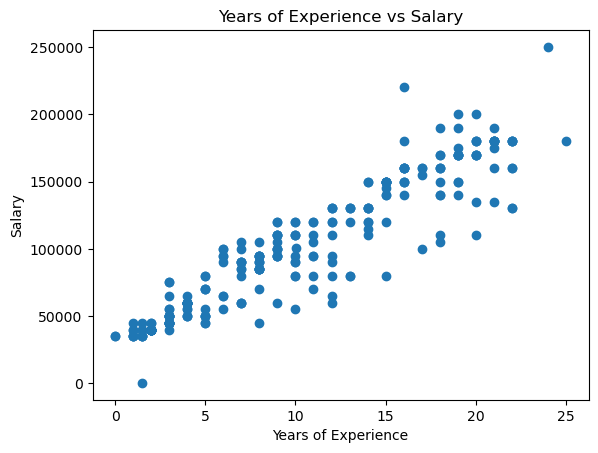

In [29]:
import matplotlib.pyplot as plt
plt.scatter(X_train, y_train)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")
plt.show()